In [3]:
#ライブラリを読み込む
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import matplotlib
import numpy as np

In [ ]:
#日本語フォント＋マイナス記号の表示を正しくする設定
matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False;

In [ ]:
#今動いてるPythonに対して pymysql と cryptography をインストールしてる

import sys
!{sys.executable} -m pip install pymysql cryptography

In [ ]:
#MySQLに接続するための設定

from sqlalchemy import create_engine

user = "root"
password = "パスワード"
host = "127.0.0.1"
database = "student_db"

engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}/{database}"
)


In [7]:
##「成績上位者」と「それ以外」を分けて、平均を比較した

query = """
WITH ranked AS (
    SELECT
        *,
        PERCENT_RANK() OVER (ORDER BY Exam_Score) AS score_rank
    FROM student_performance
)
SELECT
    CASE
        WHEN score_rank >= 0.7 THEN 'Top'
        ELSE 'Other'
    END AS score_group,
    ROUND(AVG(Hours_Studied), 2) AS avg_study,
    ROUND(AVG(Attendance), 2) AS avg_attendance,
    ROUND(AVG(Sleep_Hours), 2) AS avg_sleep,
    ROUND(AVG(Previous_Scores), 2) AS avg_previous,
    ROUND(AVG(Tutoring_Sessions), 2) AS avg_tutoring,
    ROUND(AVG(Physical_Activity), 2) AS avg_activity,
    ROUND(AVG(Exam_Score), 2) AS avg_score
FROM ranked
GROUP BY score_group;
"""


In [47]:
##SQLの結果をPythonのデータ（df）に読み込み
df = pd.read_sql(query, engine)


In [9]:
# 行を列に変換
df_plot = df.set_index("score_group").T

x = np.arange(len(df_plot.index))
width = 0.35


In [ ]:
##試験スコアにどの項目がどれくらい関係しているかを順位付きで出している

df_all = pd.read_sql("SELECT * FROM student_performance", engine)

print(df_all.corr(numeric_only=True)["Exam_Score"].sort_values(ascending=False))

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [46]:
#各列に何が入ってるか確認している
for col in ["Sleep_Hours", "Previous_Scores", "Tutoring_Sessions"]:
    print(col)
    print(df_all[col].unique())
    print("--------")

Sleep_Hours
[ 7.  8.  6. 10.  9.  5.  4.]
--------
Previous_Scores
[ 73.  59.  91.  98.  65.  89.  68.  50.  80.  71.  88.  87.  97.  72.
  74.  70.  82.  58.  99.  84. 100.  75.  54.  90.  94.  51.  57.  66.
  96.  93.  56.  52.  63.  79.  81.  69.  95.  60.  92.  77.  62.  85.
  78.  64.  76.  55.  86.  61.  53.  83.  67.]
--------
Tutoring_Sessions
[0 2 1 3 4 5 6 7 8]
--------


In [ ]:
#SQLのデータを読み込む（student_performanceを選択し）
df_all = pd.read_sql("SELECT * FROM student_performance", engine)

In [17]:
#各項目を相関の数値を可視化
cols = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score"
]

for col in cols:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

print(df_all[cols].corr()["Exam_Score"].sort_values(ascending=False))

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [18]:
#ライブラリを読み込む

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sqlalchemy import create_engine
import numpy as np

In [19]:
#文字化けしないように、日本語にする。

matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

In [20]:
#PythonからMySQLに接続するためのコード

user = "root"
password = "b4CDyamaijLcx"
host = "127.0.0.1"
database = "student_db"

engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}/{database}"
)

In [23]:
df_plot = df.set_index("score_group").T

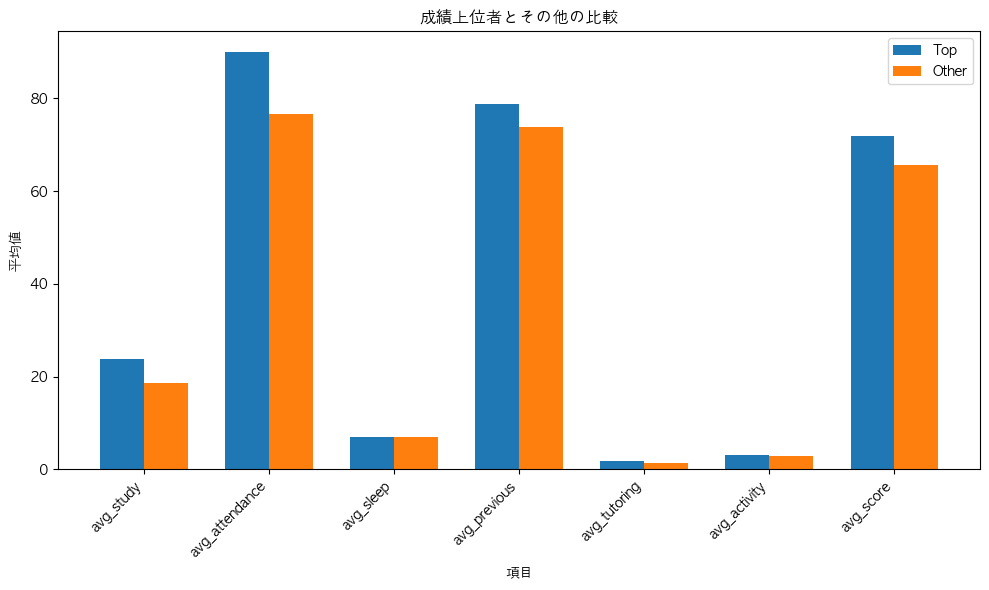

In [24]:
#Top と Other を横並びで比較する棒グラフ 作成

x = np.arange(len(df_plot.index))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, df_plot["Top"], width, label="Top")
plt.bar(x + width/2, df_plot["Other"], width, label="Other")

plt.xticks(x, df_plot.index, rotation=45, ha="right")
plt.title("成績上位者とその他の比較")
plt.xlabel("項目")
plt.ylabel("平均値")
plt.legend()
plt.tight_layout()
plt.savefig("top_vs_other_comparison_clean.png")
plt.show()

縦軸が平均なのは「グループの代表値」を比較するため

平均じゃなかったら、
人1：70
人2：80
人3：90
→バラバラすぎて比較できない

平均を使う理由
・代表地にするため
Topの平均勉強時間 = 24
Otherの平均勉強時間 = 19
・個人差を減らす
・比較しやすくするため

① 勉強時間（avg_study）
	Top：明確に高い
	Other：低い
→ 「勉強量はやっぱり効く」

② 出席率（avg_attendance）
	Top：かなり高い（約90）
	Other：低い（約77）
→「ちゃんと授業出てる人は強い」

③ 過去成績（avg_previous）
　　Top：高い（約79）
	Other：低い（約74）

④ 睡眠（avg_sleep）
　　ほぼ差がない

⑤ 塾・指導（avg_tutoring）
　　Topの方がやや多い

⑥ 運動（avg_activity）
　　むしろOtherの方が少し高い

 結果　
	1.	勉強時間
	2.	出席率
	3.	過去成績
	4.	塾（少し）
	5.	睡眠（ほぼ影響なし）
	6.	運動（ほぼ無関係）

1〜6の順で影響あることがわかった。


・結論

成績上位者は単に1つの要素が優れているのではなく、
「勉強時間」「出席率」「過去成績」が組み合わさって高い傾向が見られました。

特に、塾の受講よりも自主的な学習時間の差が大きく、
主体的な学習が重要であると考えられます。

また、睡眠時間は大きな差が見られず、
一定の生活習慣は前提条件である可能性があります。

努力したところ

 Chatgptと壁打ちしながら、
 「MySQL」　データ整備しながら足りない要素を、足したりしながら整備した
 「Python」MYSQLで整備したデータをグラフにして可視化することによって、

相関関係を見ることでもっと、データ

In [ ]:
#matplotlib.pyplotでは何回繰り返しても、高度な抽出が必要だったために
#見やすいようにseabornを使った方が良いと思った。
import seaborn as sns

In [33]:
#数値列だけに絞る（文字列列が混ざっててもOK）
num = df.select_dtypes(include="number")

In [32]:
df = pd.read_sql("SELECT * FROM student_performance", engine)

In [35]:
# 相関係数（表）
corr = num.corr(numeric_only=True)  # Pearson（普通の相関）
display(corr)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000


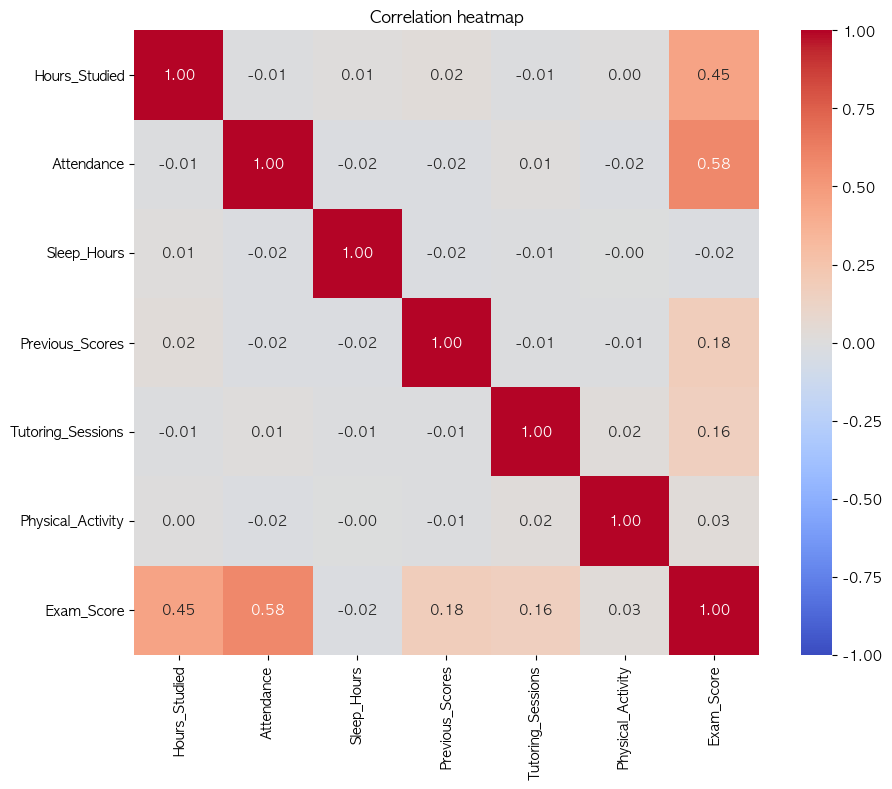

In [ ]:
# 相関ヒートマップ（相関図）

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

出席率（Attendance）
点数　（Exam_Score）
正の相関（0.58）がある
→出席率が高い人ほど、点数も高い傾向がある

真ん中の「赤い部分」は同じ項目なので考えない

In [ ]:
#ボックス図作成のためにグループ分けした

df["Score_Group"] = df["Exam_Score"].apply(
    lambda x: "Top" if x >= df["Exam_Score"].quantile(0.7) else "Other"
)

/Users/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


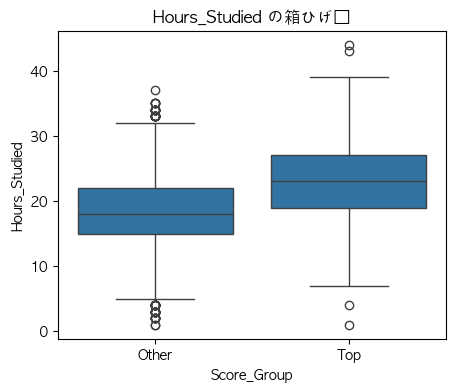

/Users/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


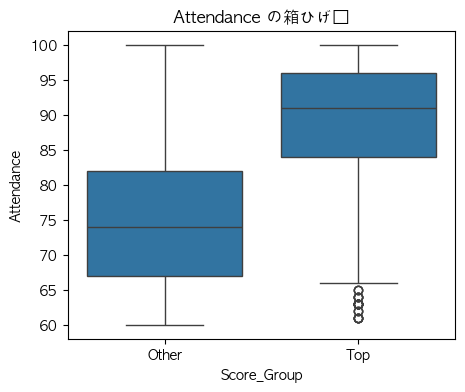

/Users/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


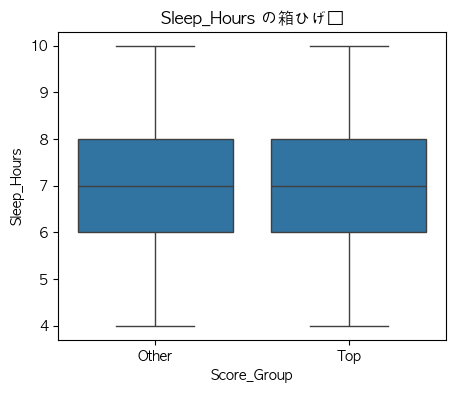

/Users/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


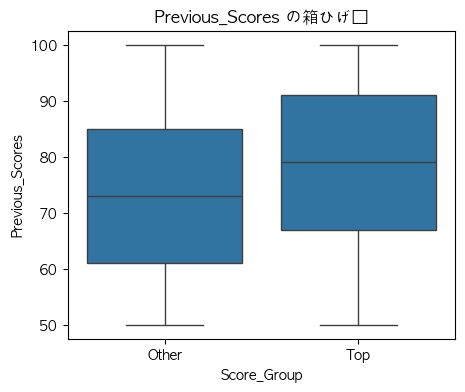

/Users/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


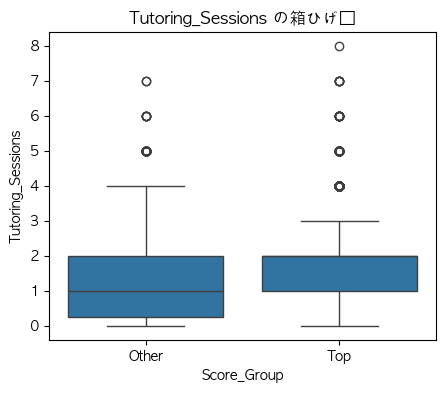

/Users/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


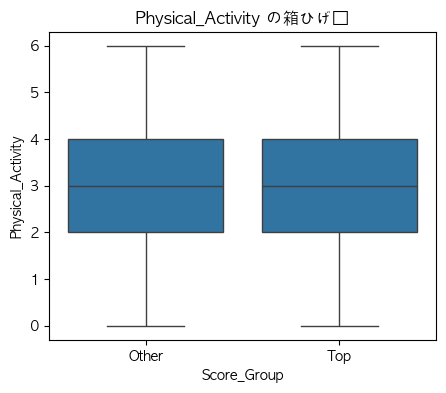

/Users/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


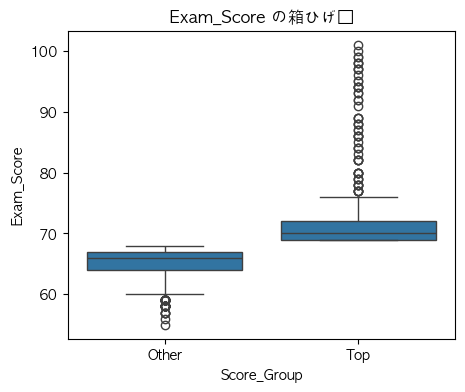

In [ ]:
#ボックス図作成

cols = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score"
]

for col in cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x="Score_Group", y=col, data=df)
    plt.title(f"{col} の箱ひげ図")
    plt.show()


・勉強時間（Hours_Studied）　　
上位層（Top）は中央値・分布ともに高く、学習時間が多いことが特徴だ。

・出席率　（Attendance）　　　　
出席率が高い方が、中央値が高く、ボックス（範囲）の位置も高い。

・睡眠時間（Sleep_Hours）　　　　　
差はなし。

・過去成績（Previous_Scores）　　
上位層はやや高い傾向が見られ、基礎学力の影響がある可能性が示唆される。

・塾利用（Tutoring_Sessions）　
上位層の方がわずかに多い傾向があるものの、差は限定的であり、決定的な要因ではないと考えられる。

・運動量（Physical_Activity）
両グループで分布に大きな差はなく、成績への影響はほとんど見られない。

・試験スコア（Exam_Score）
上位層は中央値が高く、さらに高得点の外れ値も多く見られ、一部の学生が突出して高い成績を収めていることが分かる。

総論
上位者（Top）は

① 出席率が高い
② 勉強時間が多い
③ 元の学力もやや高い

この項目が、上から当てはまる「個人」が成績上位者の特徴である。

もちろん例外は存在するので、慎重な検証は必要である。

勉強になったところ（コード、ライブラリ等）

「seaborn」を使用することによって、ボックス図、相関関係を綺麗に「可視化」することによって、各項目別の関係性を分析することができた。